In [52]:
# import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)



In [53]:
#  load the dataset

df = pd.read_csv("./bank-additional/bank-additional-full.csv",sep=";")



In [54]:
# df.to_csv("bank-additional-full-updated.csv")


In [55]:
#  basic info of data 

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [56]:
df.shape

(41188, 21)

In [57]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [58]:
# categorical data summary
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [59]:
# check missinng values 
print(df.isnull().sum())
print()
(df == "unknown").sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64



age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [60]:
# we found "unknown" value in dataset - lets replace with NaN
df.replace("unknown",np.nan,inplace=True)


In [61]:
df.isnull().sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [62]:
# all the nan values are in categorical column so we need to replace iit withh MODE of column
error_col = ['job','marital','education','default','housing','loan']

for col in df[error_col]:
    
    df.fillna(df[col].mode())



In [63]:
df.isnull().sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [64]:
# check unique values
# print(df['day_of_week'].unique())

# print(df['month'].unique()) # there is no jan feb

for col in df.select_dtypes(include='object'):
    print(col," : ",df[col].unique().tolist())

job  :  ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', nan, 'entrepreneur', 'student']
marital  :  ['married', 'single', 'divorced', nan]
education  :  ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', nan, 'university.degree', 'illiterate']
default  :  ['no', nan, 'yes']
housing  :  ['no', 'yes', nan]
loan  :  ['no', 'yes', nan]
contact  :  ['telephone', 'cellular']
month  :  ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
day_of_week  :  ['mon', 'tue', 'wed', 'thu', 'fri']
poutcome  :  ['nonexistent', 'failure', 'success']
y  :  ['no', 'yes']


In [65]:
df.columns = df.columns.str.strip().str.lower().str.replace('.','_')

        

In [66]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,NaN,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,NaN,no,no,cellular,aug,mon,33,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,127,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,123,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df.columns # ensures target variable is y

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

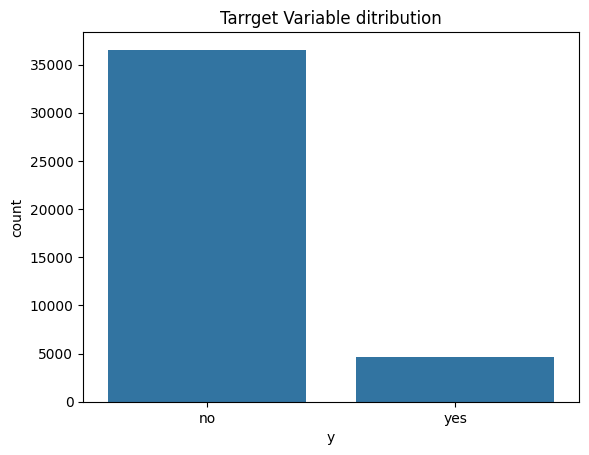

y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64

In [69]:
sns.countplot(x='y',data=df)
plt.title("Tarrget Variable ditribution")
plt.show()

df['y'].value_counts(normalize=True) * 100

In [70]:
# Univariate Analysis

# numerical columns
num_col = df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')

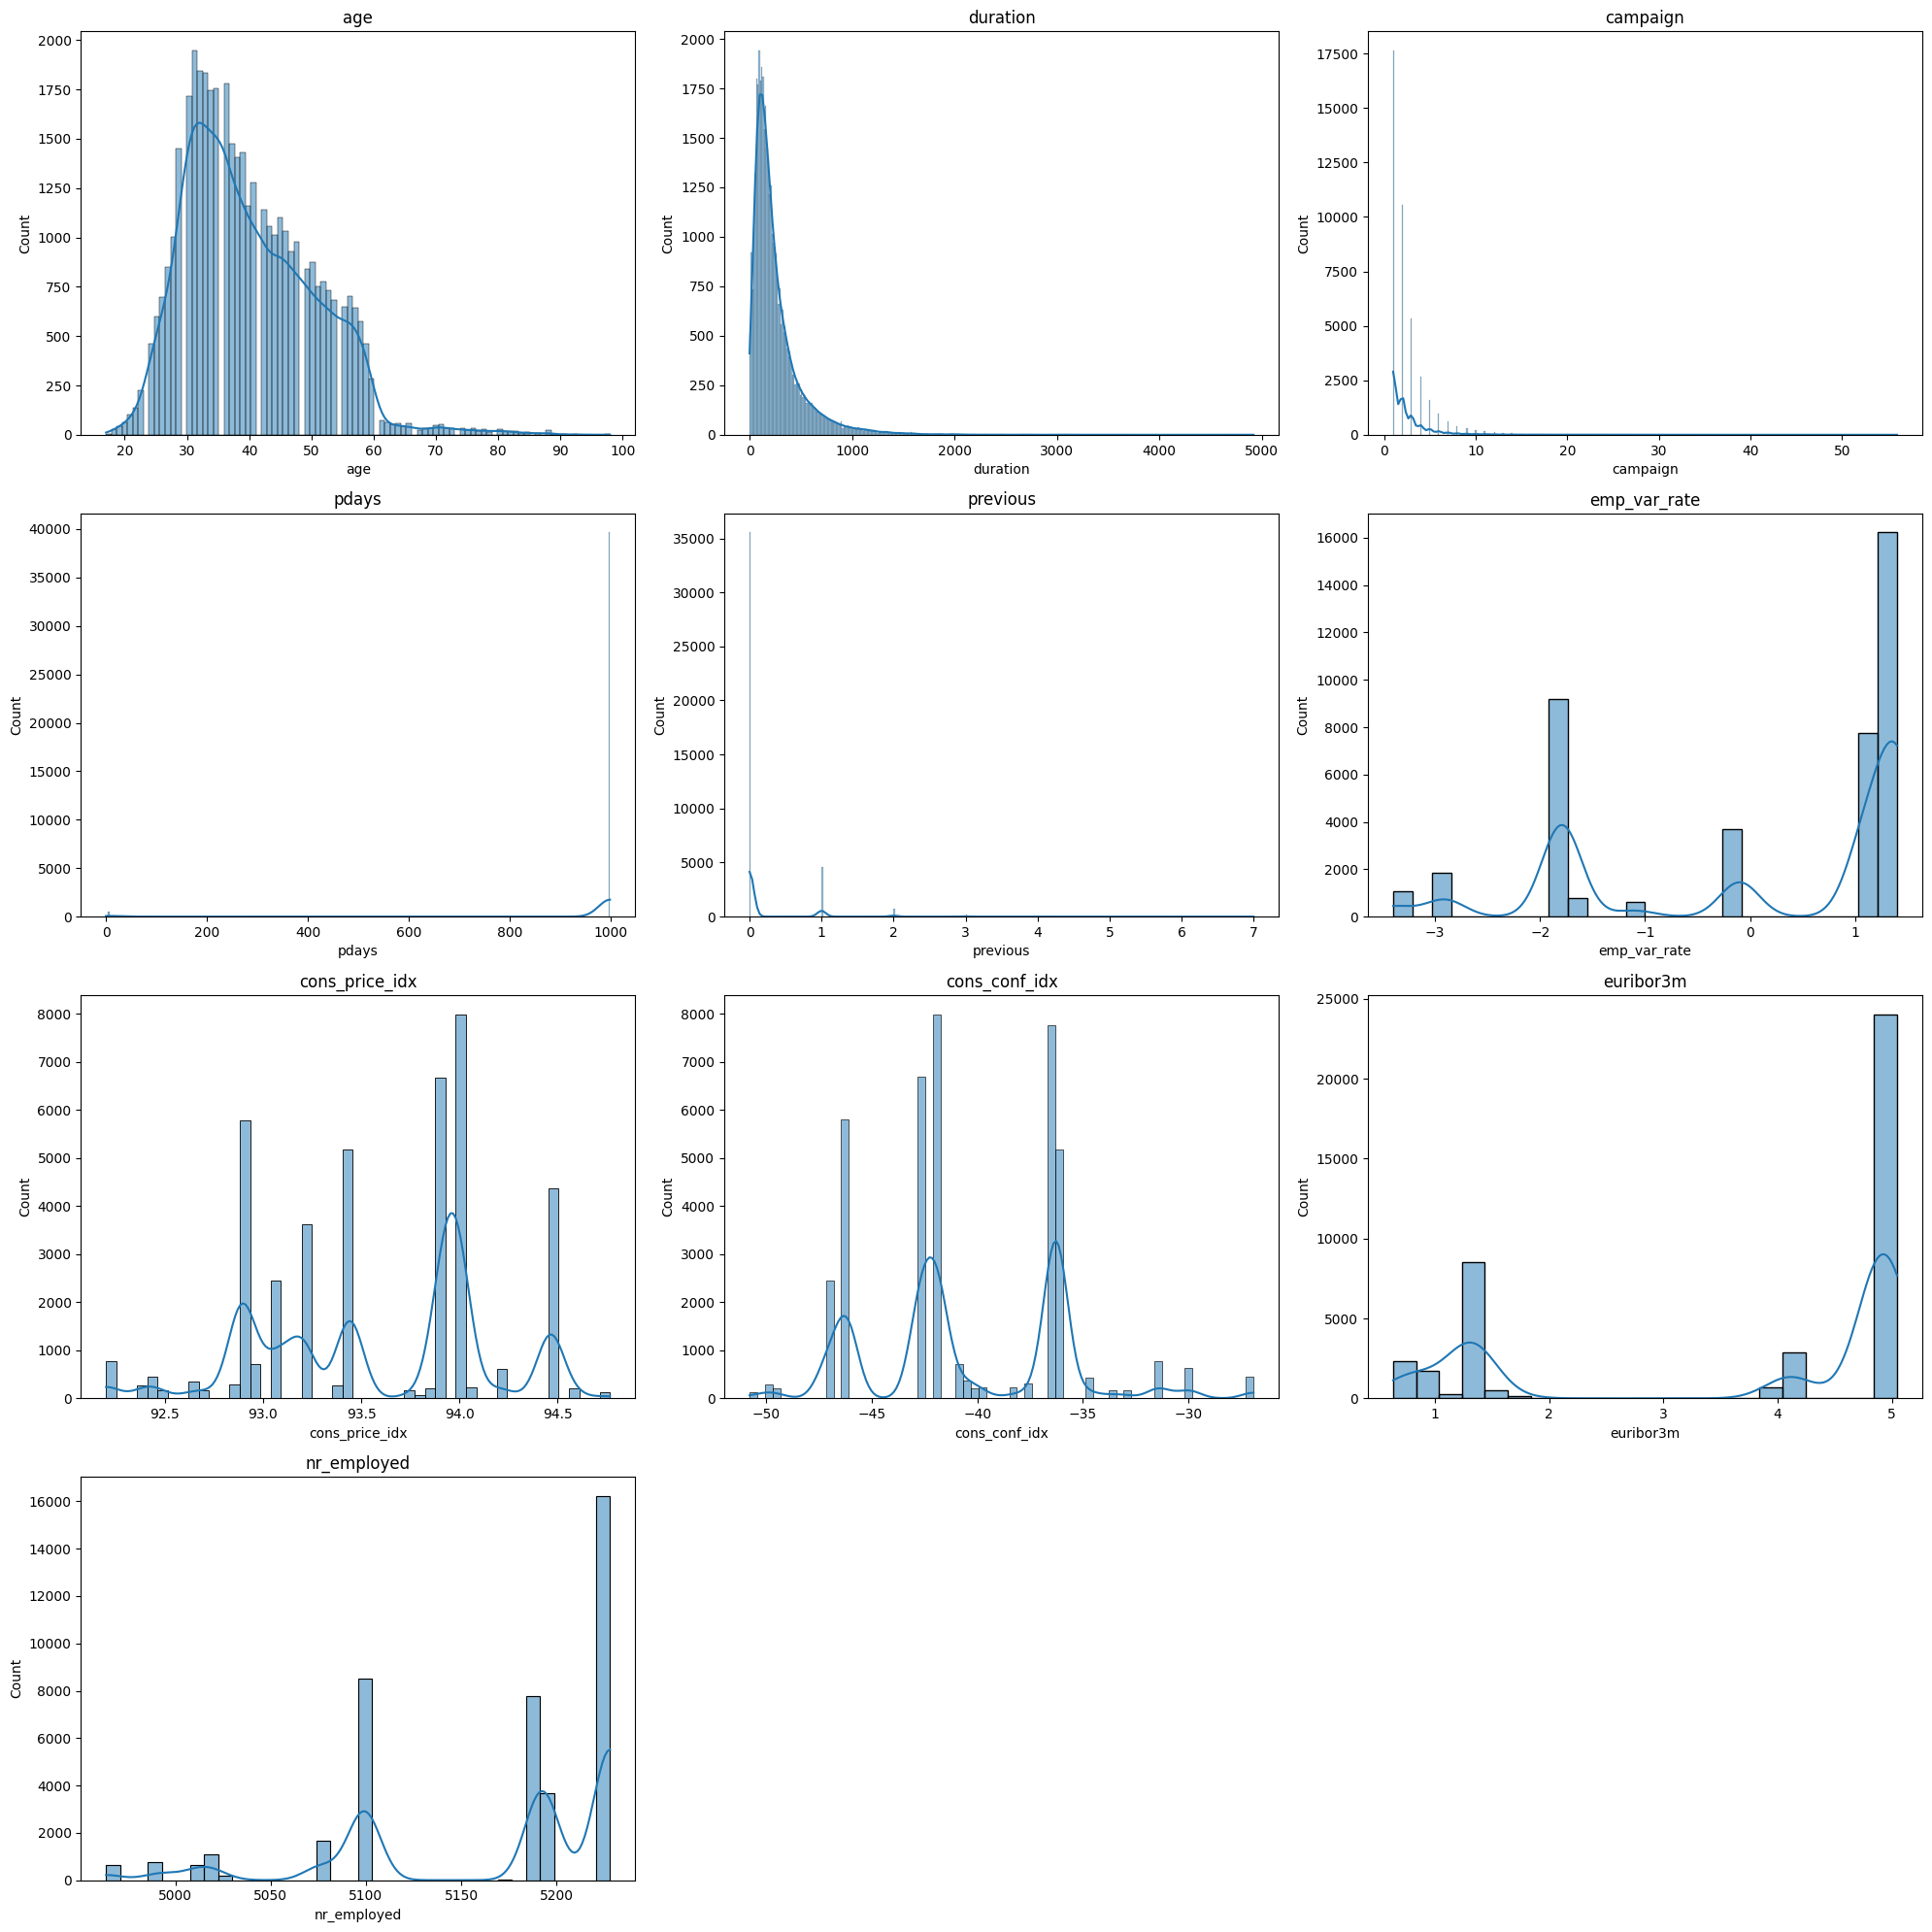

In [71]:
plt.figure(figsize=(20,20))

for i, col in enumerate(df.select_dtypes(include=['number']).columns[:16], 1):
    plt.subplot(4,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


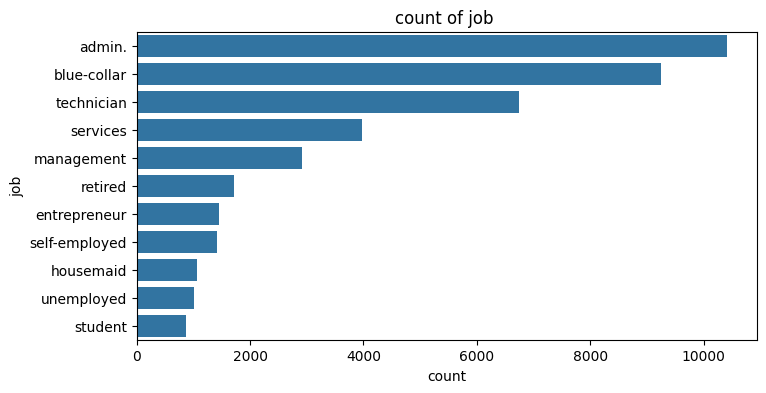

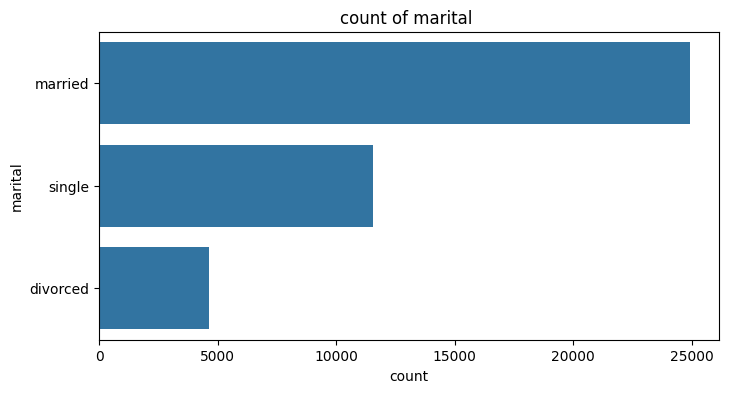

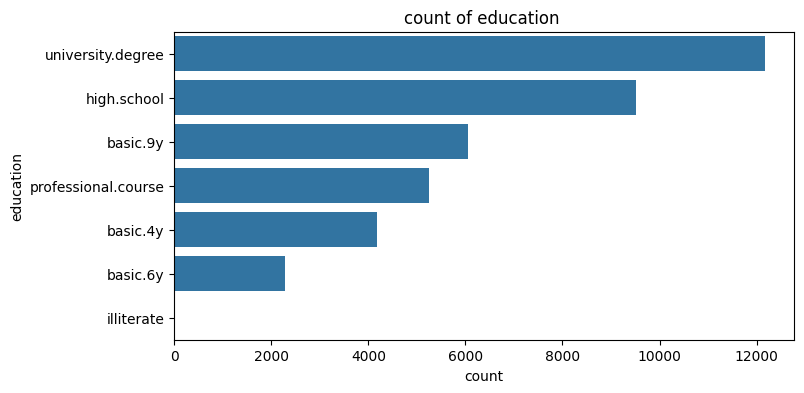

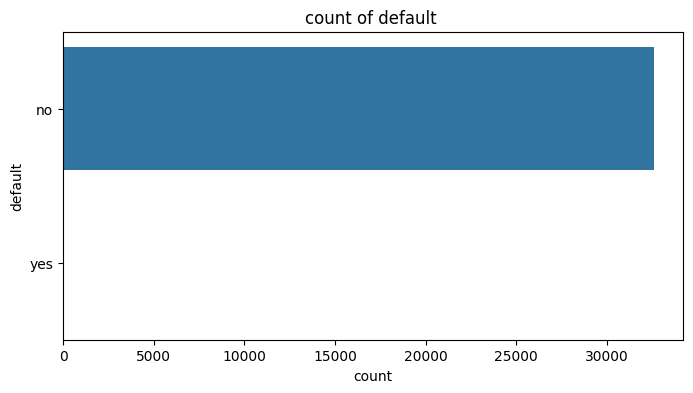

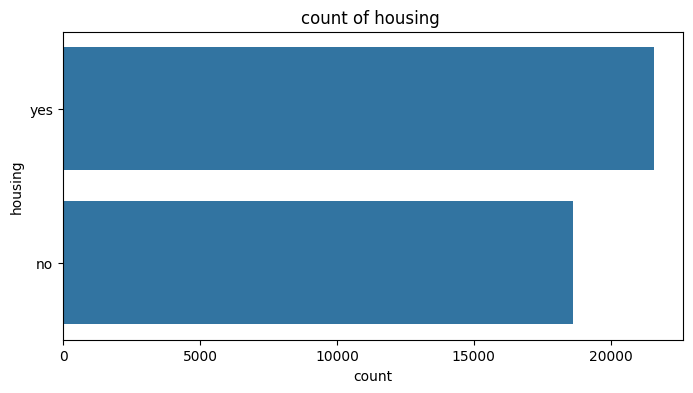

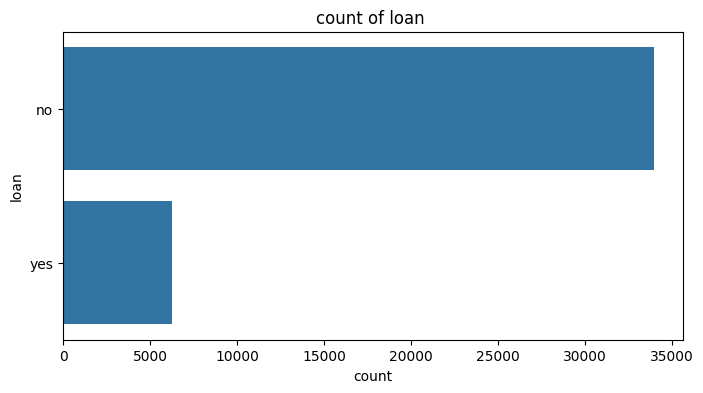

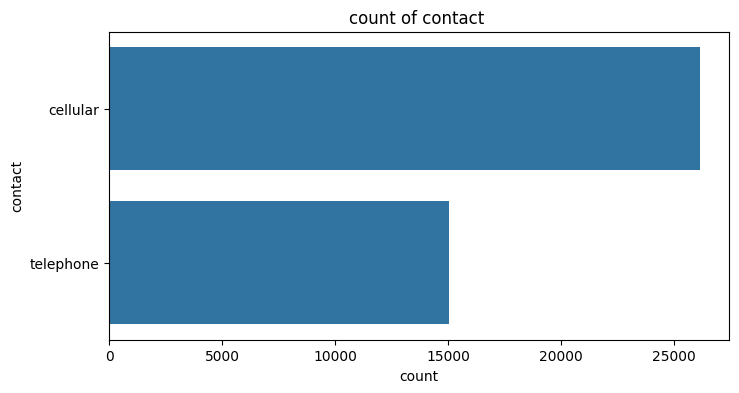

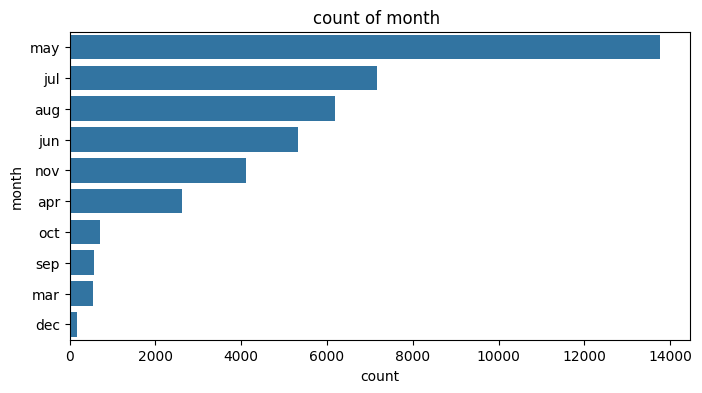

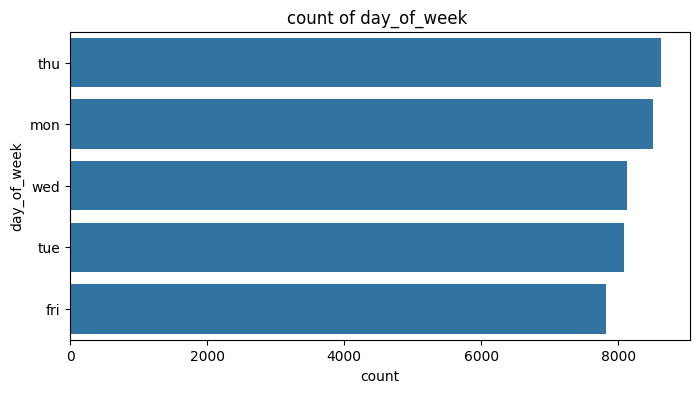

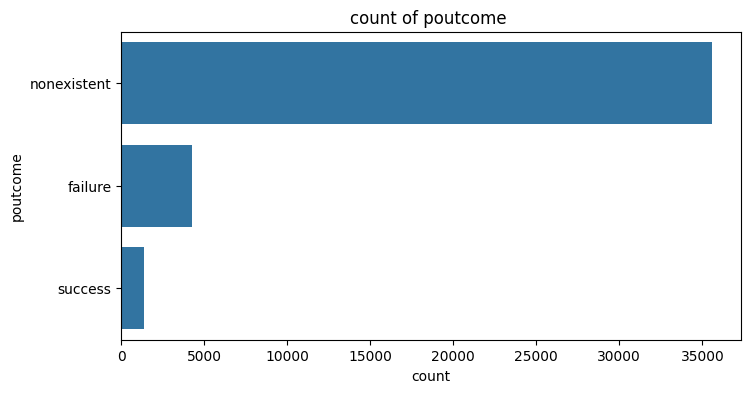

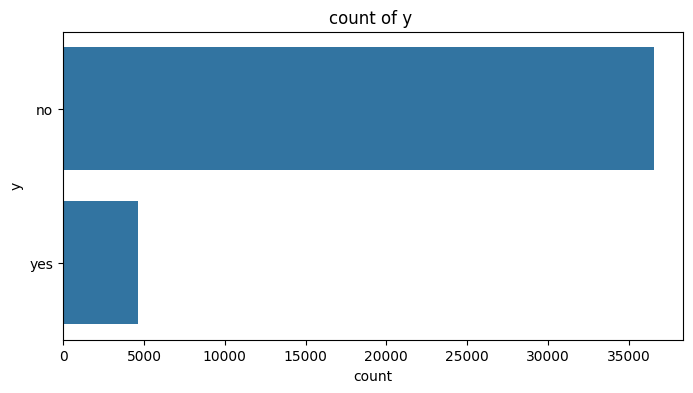

In [72]:
cat_cols = df.select_dtypes(include="object")

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col , data=df, order=df[col].value_counts().index)
    plt.title(f"count of {col} ")

## bivariate analysis (feature vs target)



In [73]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

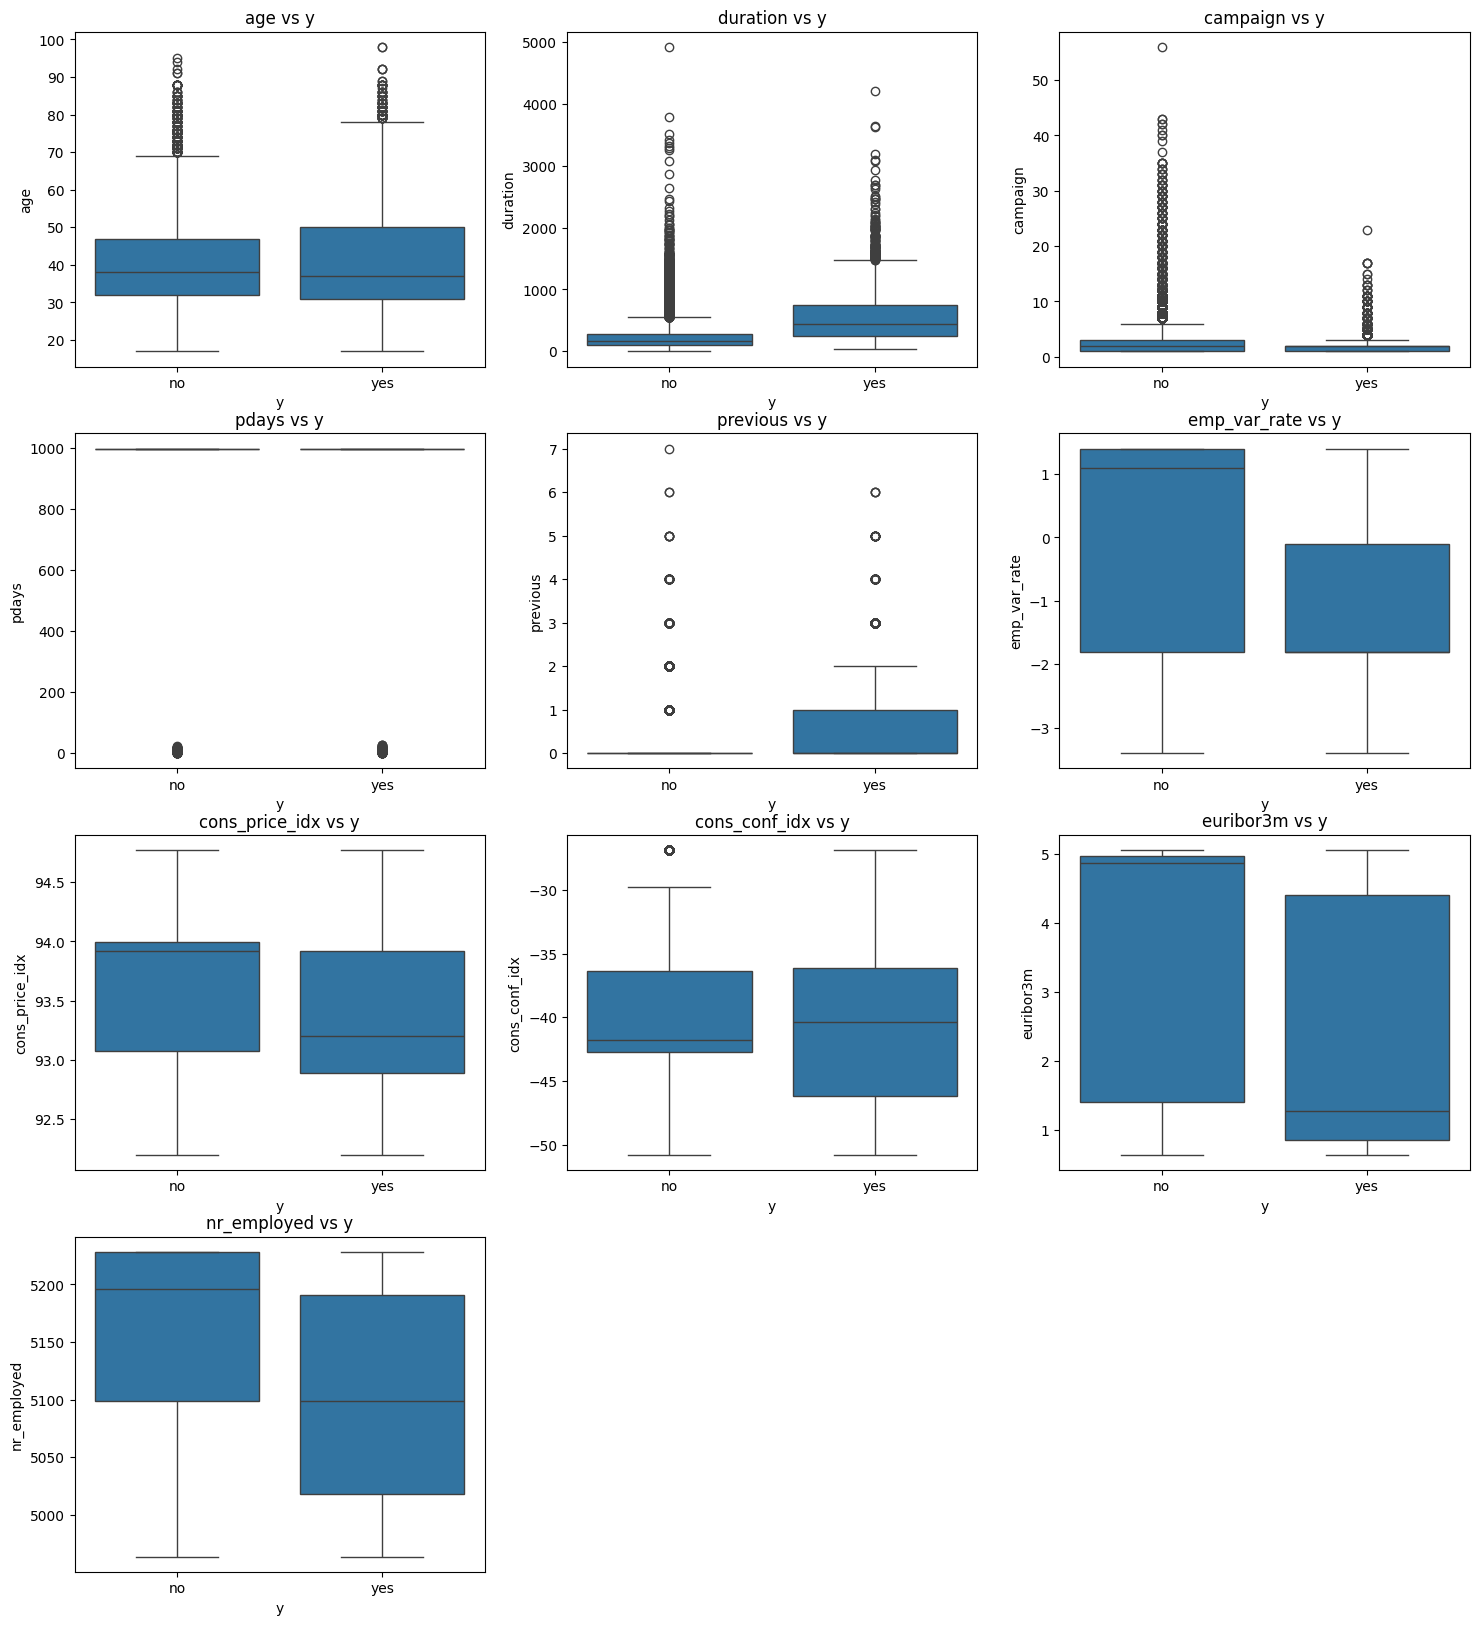

In [74]:
#  Numerical Column

plt.figure(figsize=(18,20))
for i, col in enumerate(num_col,1):
    plt.subplot((len(num_col)+2)//3,3,i)

    sns.boxplot(x='y',y=col,data=df)
    plt.title(f"{col} vs y")

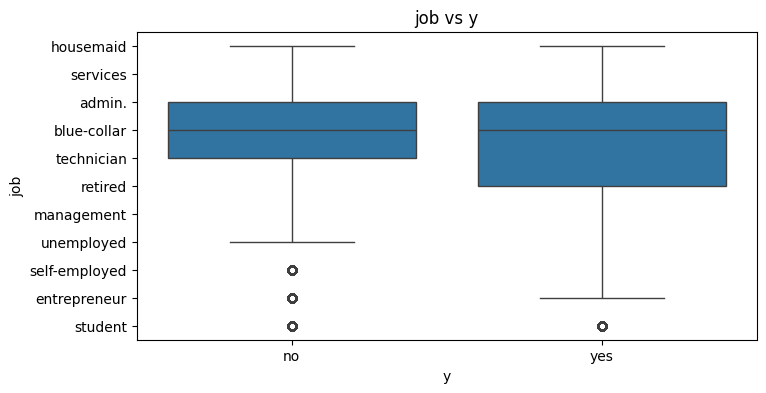

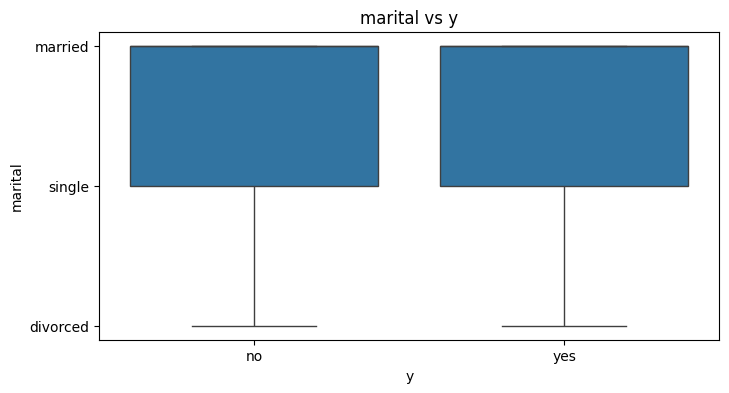

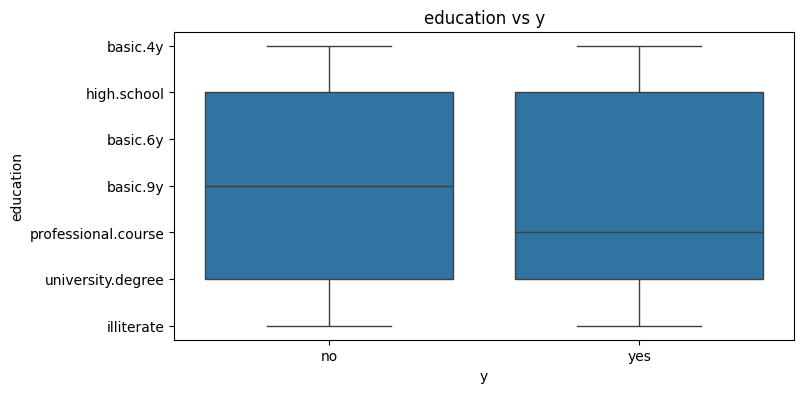

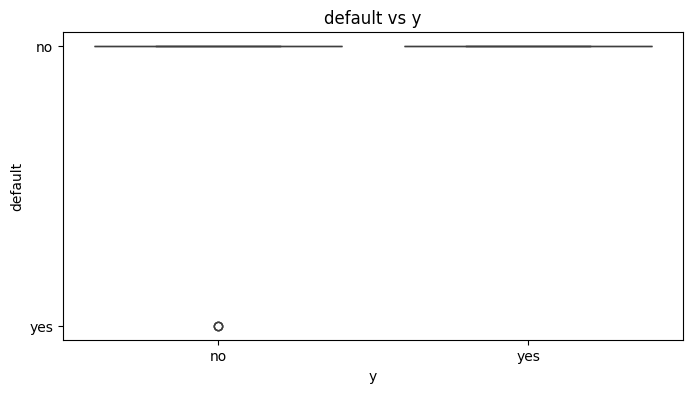

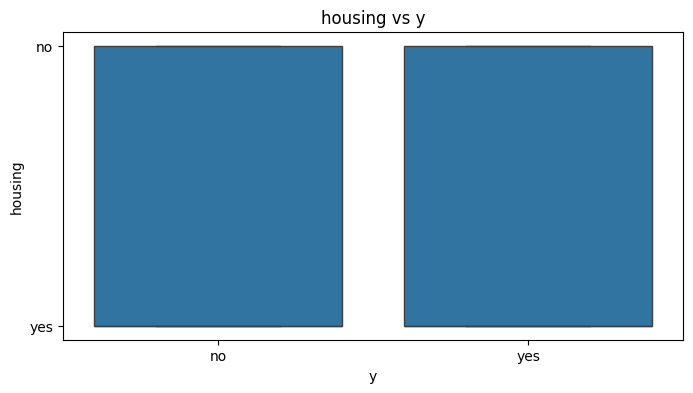

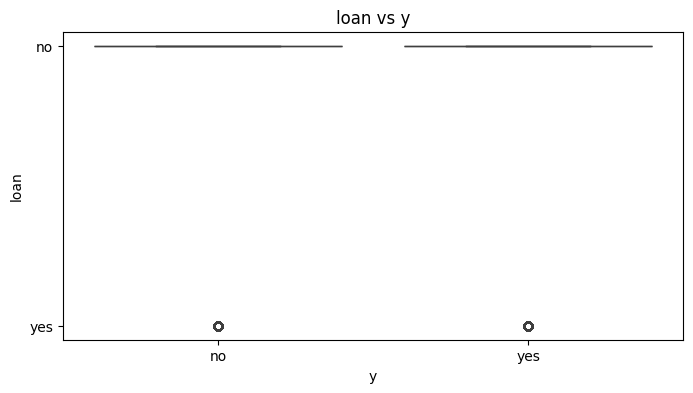

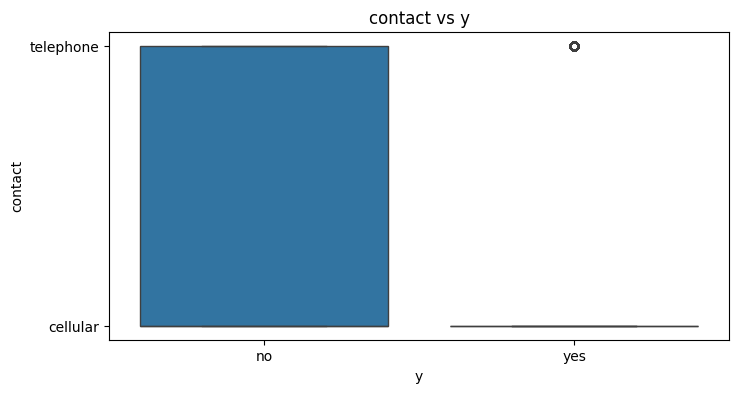

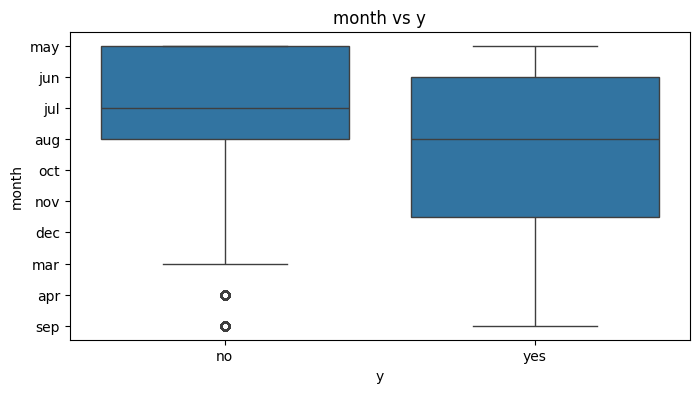

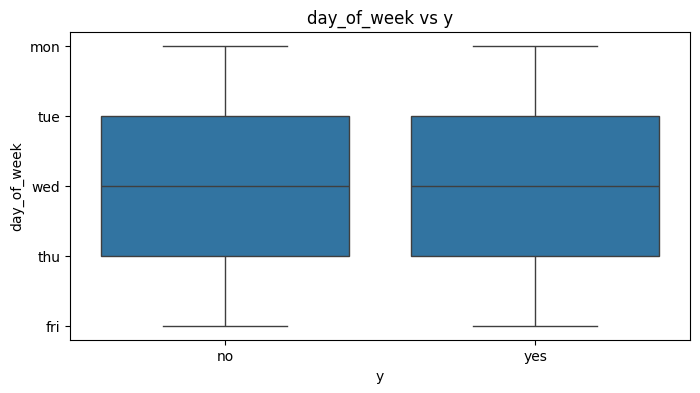

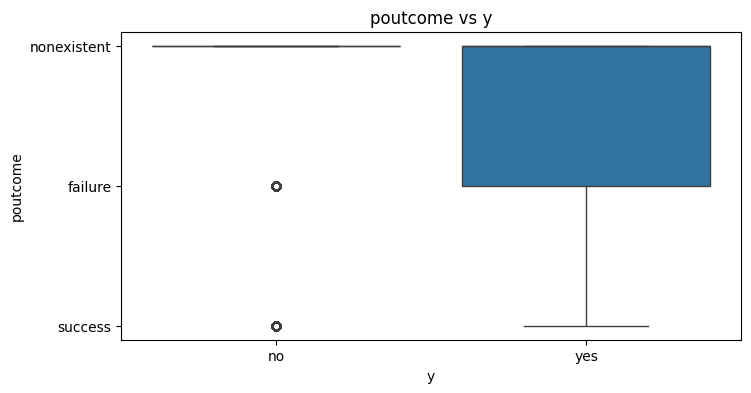

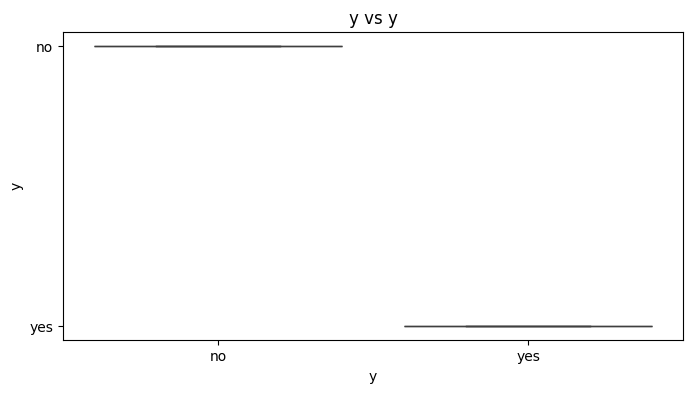

In [75]:
#  categorical column

for  col in cat_cols:
    plt.figure(figsize=(8,4))

    sns.boxplot(x='y',y=col,data=df)
    plt.title(f"{col} vs y")

In [76]:
# df.to_csv("updated v1.csv")

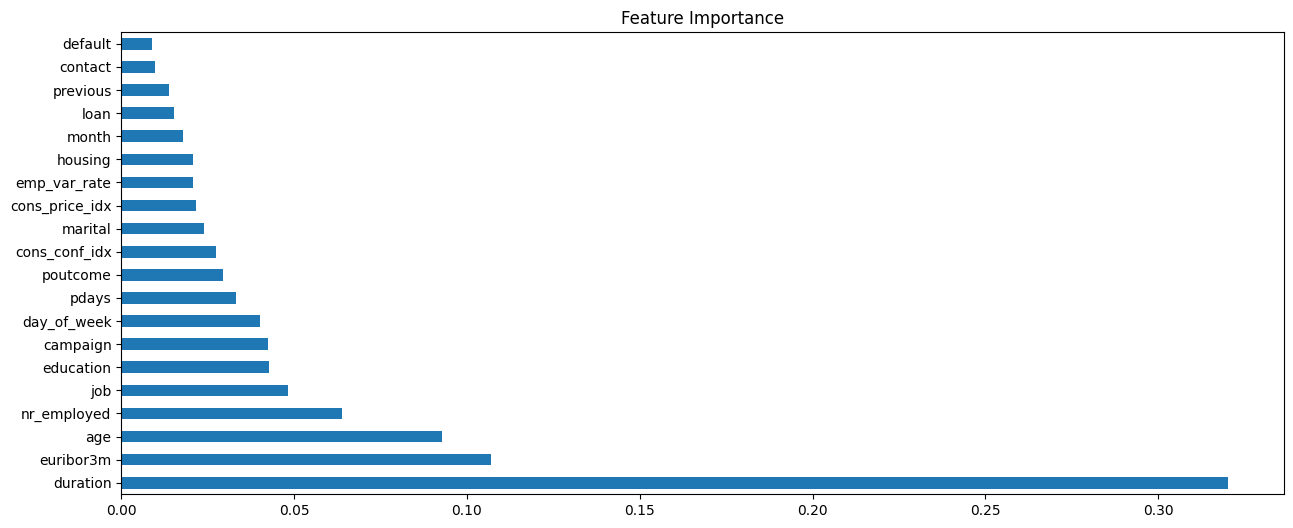

default     0.008726
contact     0.009814
loan        0.015343
previous    0.013650
dtype: float64


In [77]:

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


# Encode target column
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Encode all object columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('y', axis=1)
y = df['y']

# Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(15,6))
feat_importances.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# Print specific columns' importance

print(feat_importances[['default', 'contact', 'loan', 'previous']])


In [78]:
# from this analysis : ['default',  'contact'] colums dooes not affect the target so its better to delete them

In [79]:
# df.drop(['default', 'poutcome', 'loan', 'contact'],axis = 1,  inplace=True)

## Correlation Analysis 

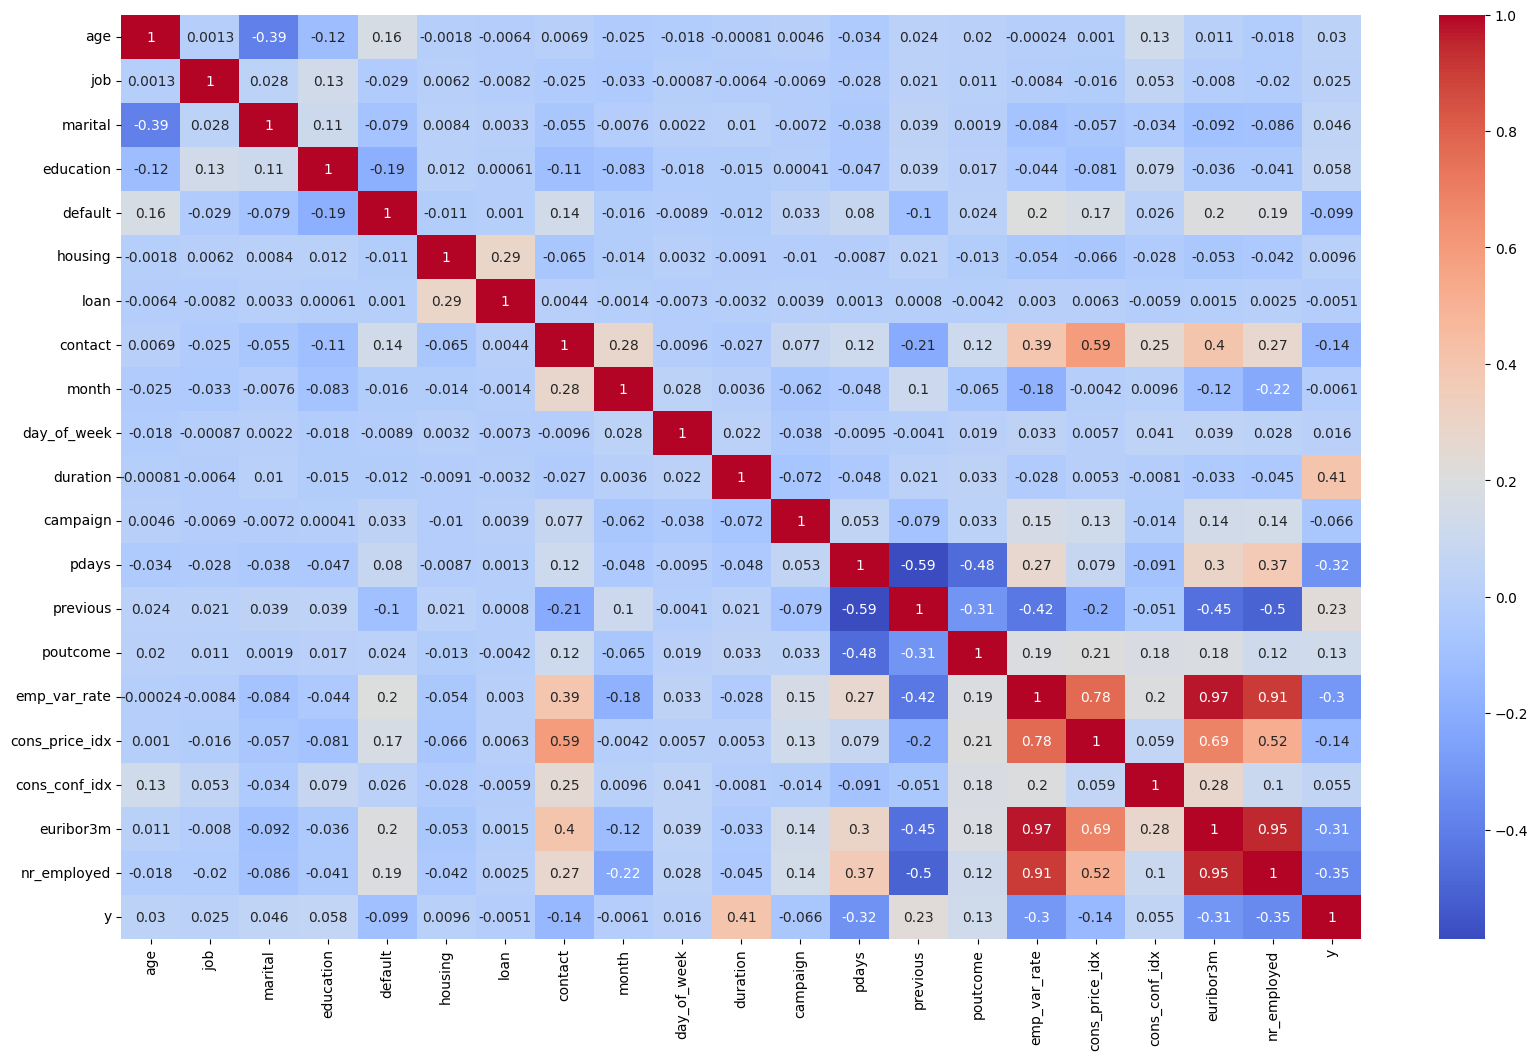

In [80]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.savefig("heatmap.png",dpi=300, bbox_inches='tight')

## Outliers

In [81]:
# for col in df.select_dtypes(include=['int64','float64']):
#     plt.figure()
#     sns.boxplot(x=df[col])

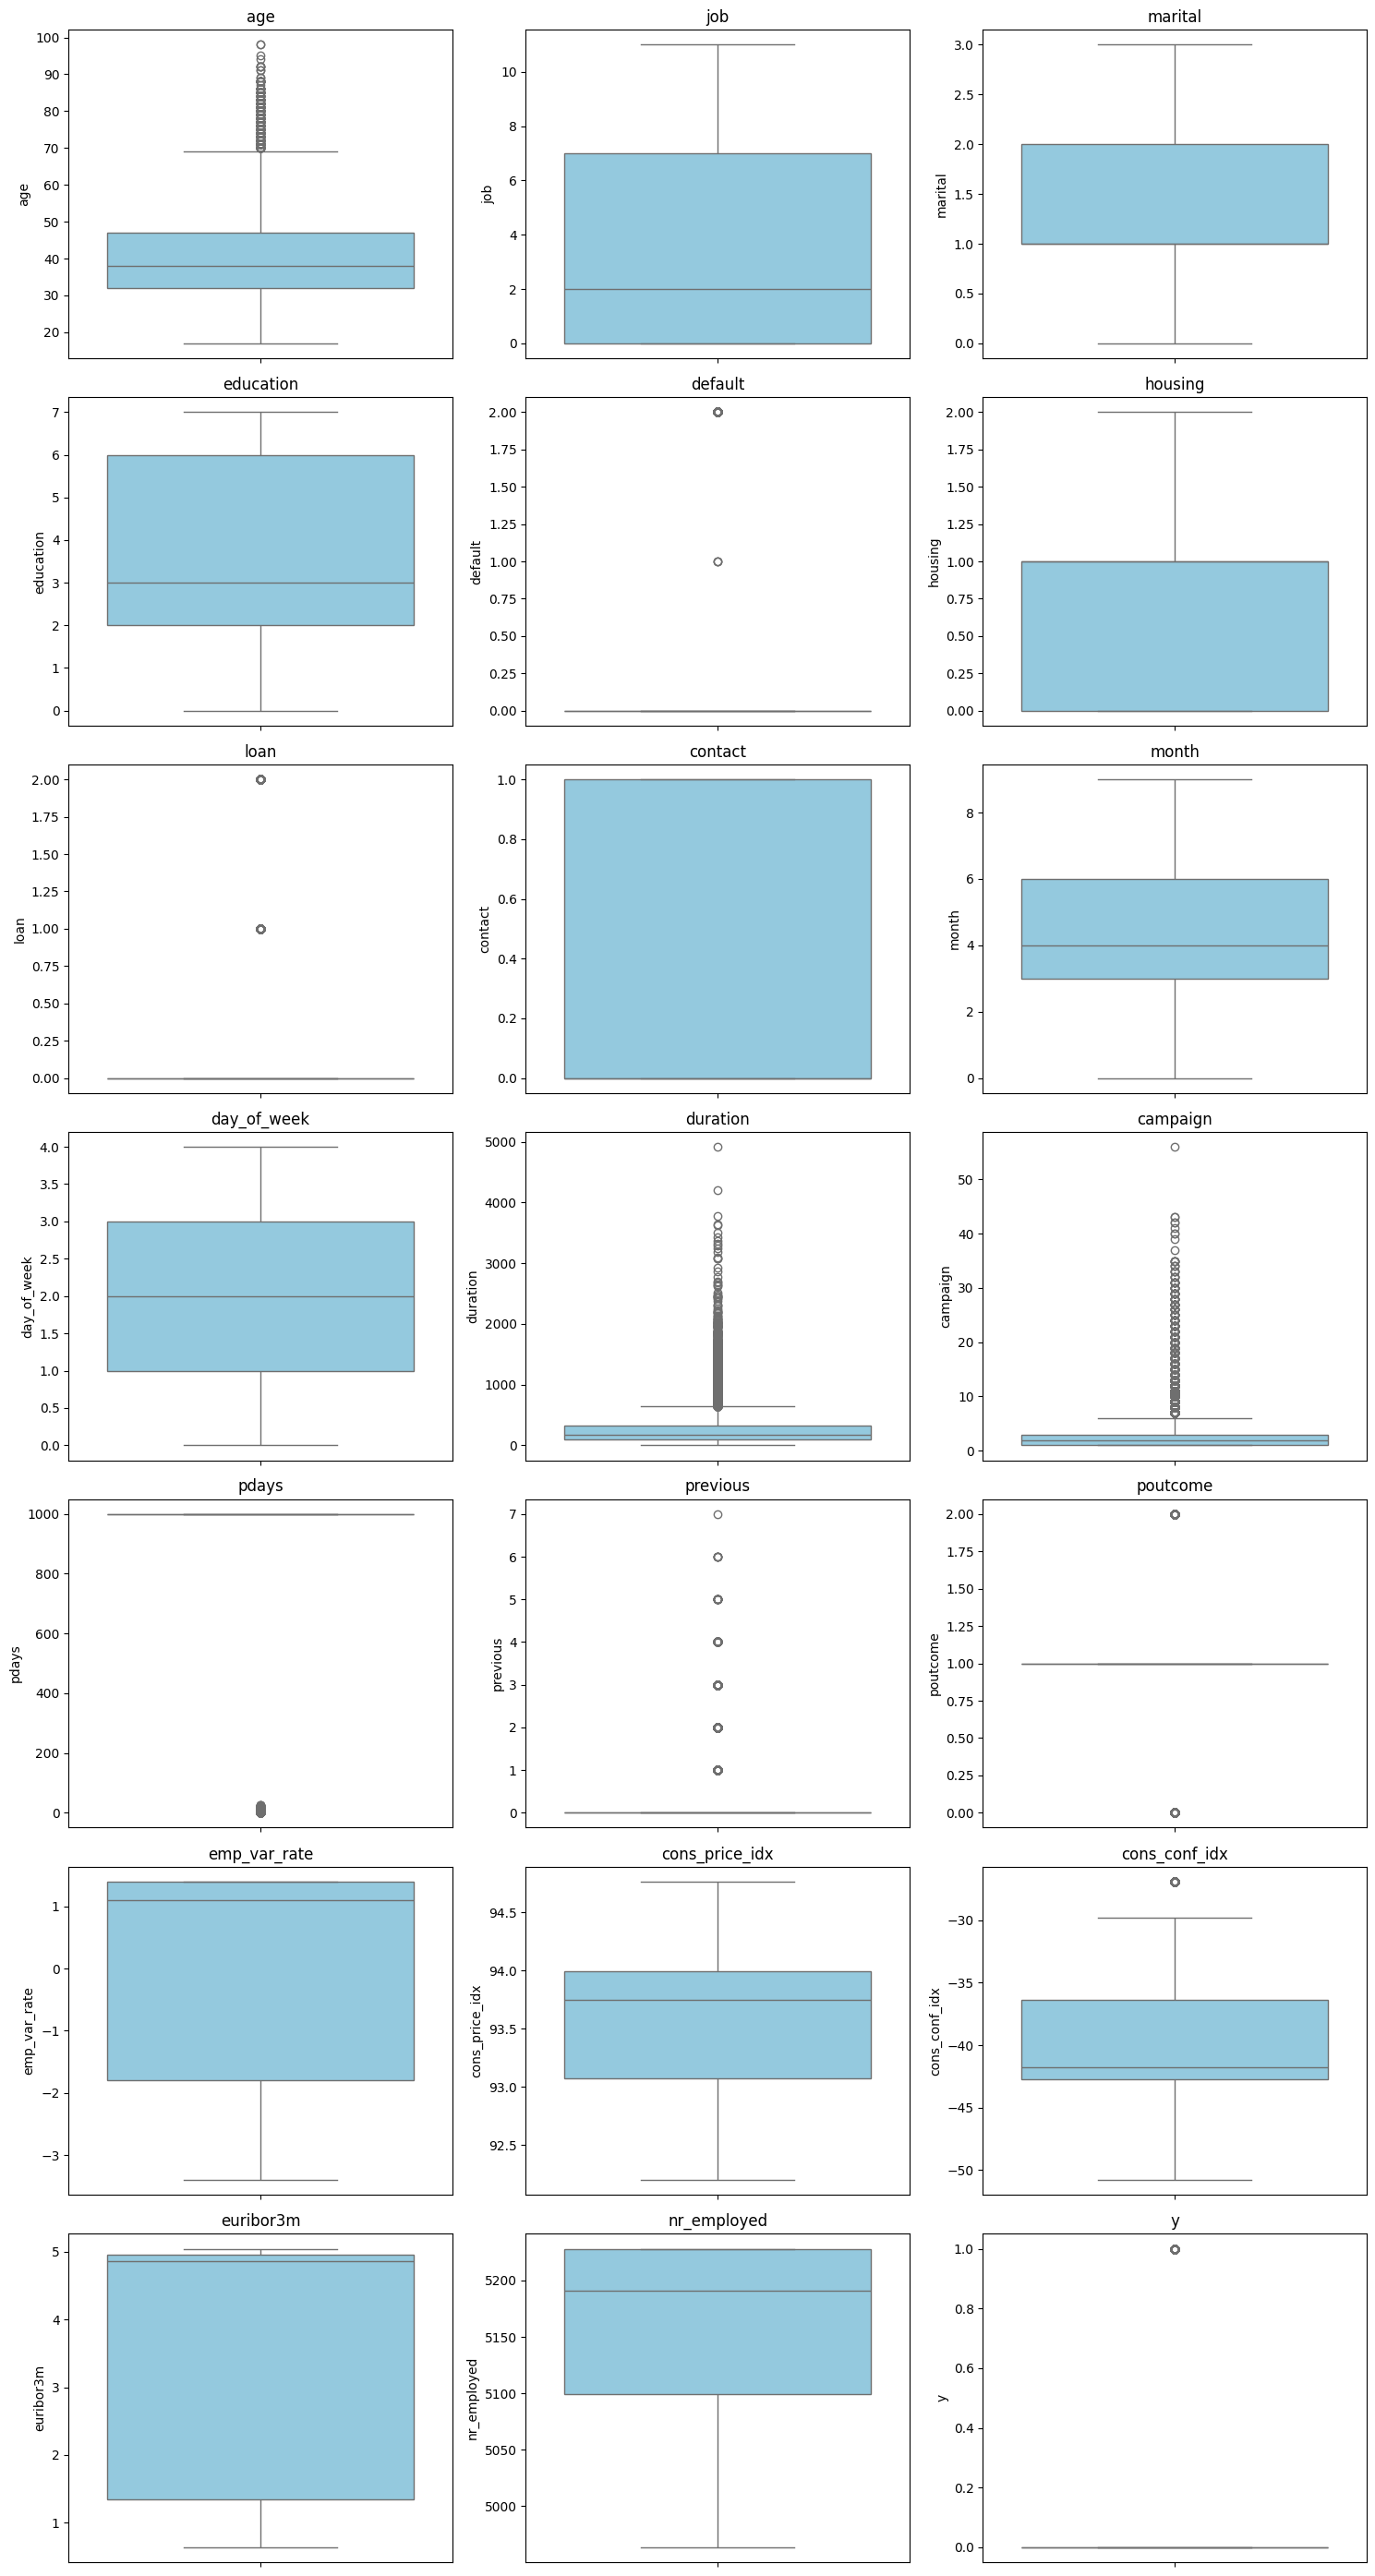

In [82]:
from self_made_functions import boxplot as bp 
bp.plot_all_boxplots(df)

In [83]:
# outliers in col [ 'age', 'duration', 'capaign'  ] 

In [84]:
df[['age','duration','campaign']].describe()

,age,duration,campaign
count,41176.00000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879
std,10.42068,259.305321,2.770318
min,17.00000,0.000000,1.000000
25%,32.00000,102.000000,1.000000
50%,38.00000,180.000000,2.000000
75%,47.00000,319.000000,3.000000
max,98.00000,4918.000000,56.000000


In [85]:
'''
IQR Rule Formula : Q3 - Q1 
lower bound = Q1 - 1.5 * IQR
higher bound = Q3 + 1.5 * IQR

if (value < lower bound) and (value > higher bound)  = outlier

'''


'\nIQR Rule Formula : Q3 - Q1 \nlower bound = Q1 - 1.5 * IQR\nhigher bound = Q3 + 1.5 * IQR\n\nif (value < lower bound) and (value > higher bound)  = outlier\n\n'

In [86]:
q1 = df['age'].quantile(.25)
q2 = df['age'].quantile(.50)
q3 = df['age'].quantile(.75)
q4 = df['age'].quantile(1)

iqr = q3 - q1 # 15
lb = q1 - 1.5 * iqr
hb = q3 + 1.5 * iqr

outlier = df[(df.age > hb) | (df.age < lb)]
outlier.shape

(468, 21)

In [87]:
outlier[outlier['age']>95]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
38452,98,5,1,0,2,1,0,0,8,0,476,1,2,2,2,-3.4,92.431,-26.9,0.73,5017.5,1
38455,98,5,1,0,2,1,0,0,8,0,272,2,999,0,1,-3.4,92.431,-26.9,0.73,5017.5,1


In [88]:
# removing all outliers cause data loss 
df.age.max()  # 98
# logically i am removinng age > 80

df = df[df['age'] <=80]
    
df['age'].max()


np.int64(80)

<Axes: ylabel='age'>

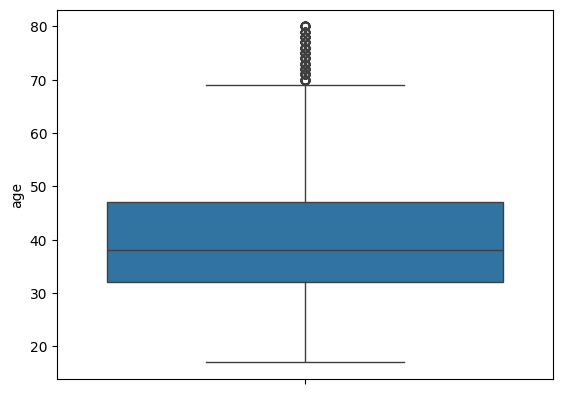

In [89]:
# let see outliers in boxplot
sns.boxplot(data=df.age)

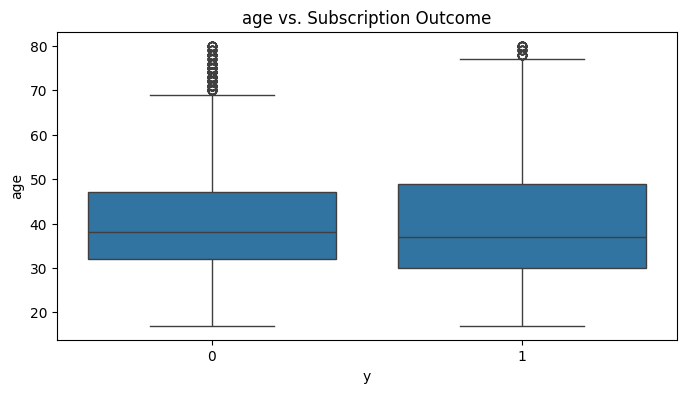

In [119]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='age',data=df)
plt.title("age vs. Subscription Outcome")
# plt.show()
plt.savefig("agge vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

In [90]:
q1 = df['duration'].quantile(.25)
q2 = df['duration'].quantile(.50)
q3 = df['duration'].quantile(.75)
q4 = df['duration'].quantile(1)

iqr = q3 - q1 # 217
lb = q1 - 1.5 * iqr
hb = q3 + 1.5 * iqr

outlier = df[(df.duration > hb) | (df.duration < lb)]
outlier


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
37,52,9,1,2,0,1,0,1,6,1,1666,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
57,45,7,1,3,2,1,0,1,6,1,787,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
61,51,1,1,2,0,1,0,1,6,1,812,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
75,41,1,0,0,2,1,0,1,6,1,1575,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,1
83,49,2,1,6,2,1,0,1,6,1,1042,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41147,25,9,2,5,0,1,0,0,7,0,712,2,19,1,2,-1.1,94.767,-50.8,1.040,4963.6,1
41153,67,3,0,5,0,1,0,0,7,1,655,2,5,5,2,-1.1,94.767,-50.8,1.039,4963.6,1
41160,33,0,1,6,0,0,0,0,7,3,843,1,999,0,1,-1.1,94.767,-50.8,1.035,4963.6,1
41164,54,0,1,5,0,0,0,0,7,3,1868,2,10,1,2,-1.1,94.767,-50.8,1.035,4963.6,1


In [91]:
#  duration is in seconds; 
# 
# lets convers it into minutes
# df = df[df['duration'] / 60]



In [92]:
1500/60


25.0

<Axes: ylabel='duration'>

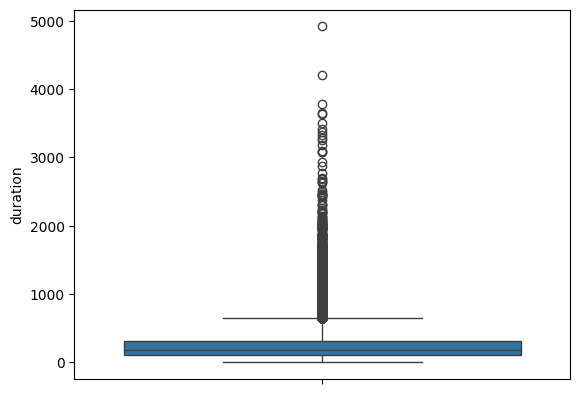

In [93]:
sns.boxplot(data=df['duration'])

1500


<Axes: ylabel='duration'>

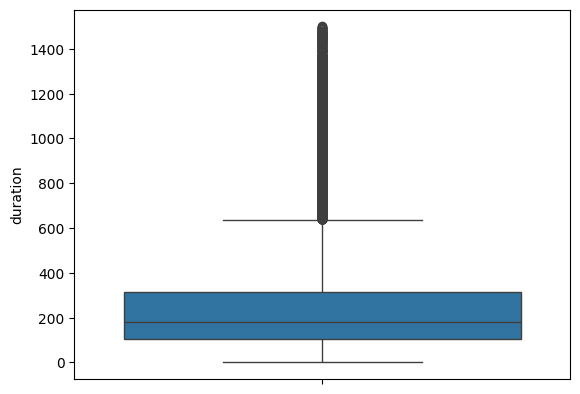

In [ ]:
# about duratiionn there are outlers froom 1000 - 5000 
# i think on call no more talk more than 10 minutes 
# but lets we take 1500 sec max means 25 min they are talked and i am removing all the rows more than 1500

df = df[df['duration'] <= 1500] 
print(df['duration'].max())
sns.boxplot(data=df['duration'])

# sommetimes removing all outliers causes of data loss and imperfect model traning


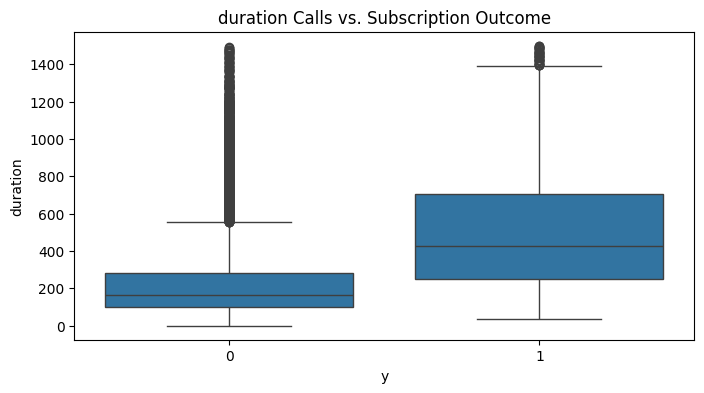

In [118]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='duration',data=df)
plt.title("duration Calls vs. Subscription Outcome")
# plt.show()
plt.savefig("duration Calls vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

In [95]:
# lets handle campaign outlier 

q1 = df['campaign'].quantile(.25)
q2 = df['campaign'].quantile(.50)
q3 = df['campaign'].quantile(.75)
q4 = df['campaign'].quantile(1)

iqr = q3 - q1 # 15
lb = q1 - 1.5 * iqr
hb = q3 + 1.5 * iqr

outlier = df[(df.campaign > hb) | (df.campaign < lb)]
outlier.shape


(2398, 21)

<Axes: ylabel='campaign'>

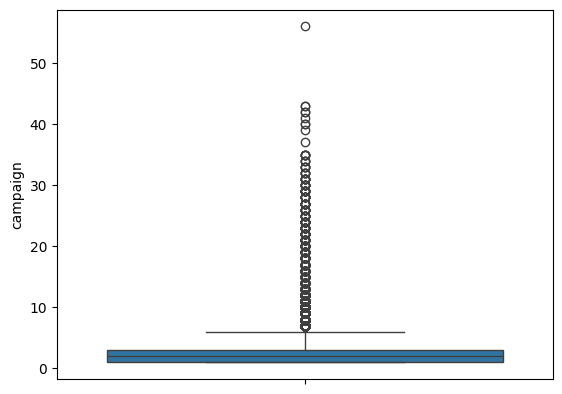

In [96]:
sns.boxplot(data=df['campaign'])

In [ ]:
df[(df['campaign']>15) & (df['y'] == 1) ]

# Almost no one who was called more than 15 times actually bought the product.

# 5 / df.shape[0] *100   --> 0.01%


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
3219,39,1,1,2,0,0,0,1,6,2,651,23,999,0,1,1.1,93.994,-36.4,4.860,5191.0,1
10162,44,0,2,6,0,1,0,1,4,2,541,17,999,0,1,1.4,94.465,-41.8,4.958,5228.1,1
17284,59,5,1,3,0,1,0,0,3,0,1448,17,999,0,1,1.4,93.918,-42.7,4.962,5228.1,1
17655,50,0,1,6,0,0,0,1,3,1,1076,17,999,0,1,1.4,93.918,-42.7,4.962,5228.1,1
29980,31,9,2,6,0,0,0,1,0,3,207,17,999,0,1,-1.8,93.075,-47.1,1.405,5099.1,1


In [ ]:
4451 / df.shape[0] *100 

#  10 % outliers in campaign

10.895694107855377

<Axes: ylabel='campaign'>

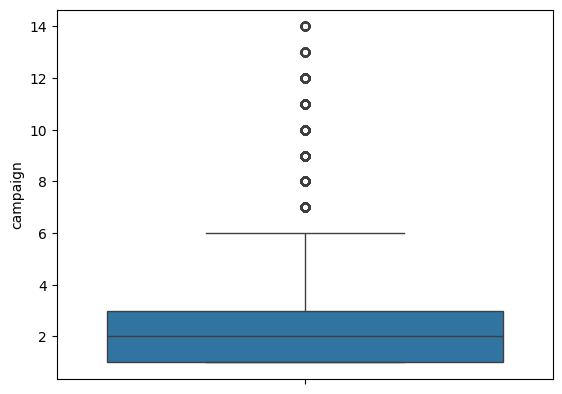

In [109]:
# If a customer hasn’t agreed after 15 calls, they probably never will.

# Continuing to call them wastes time, money, and human resources.

# It’s smarter for the bank to redirect those calls to new customers instead.

# — removing those entries (or capping at 15) is justified and data-driven.

df = df[df['campaign'] < 15]

sns.boxplot(data=df['campaign'])

In [110]:
df.shape

(40445, 21)

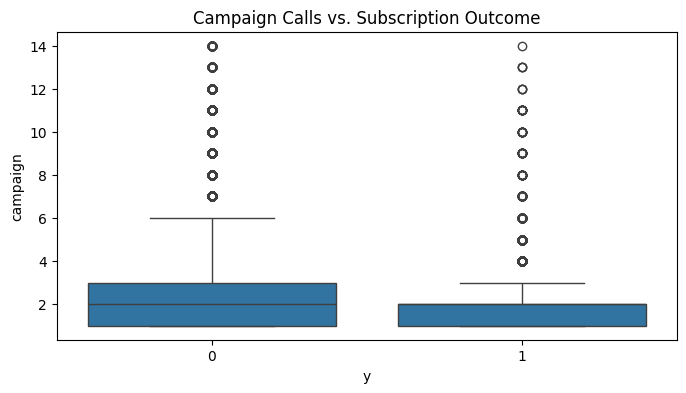

In [115]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='campaign',data=df)
plt.title("Campaign Calls vs. Subscription Outcome")
# plt.show()
plt.savefig("Campaign Calls vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

In [116]:
# ohh no by viz... this we can see outliers are more than 6
df = df[df['campaign'] < 6]


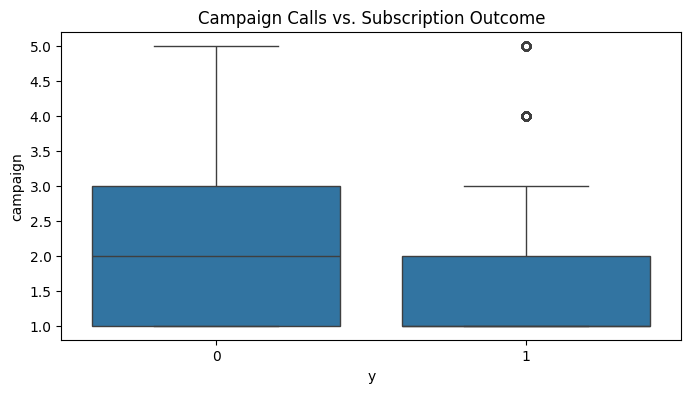

In [117]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='campaign',data=df)
plt.title("Campaign Calls vs. Subscription Outcome")
# plt.show()
plt.savefig("Campaign Calls vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

## Final Summmary